In [1]:
!pip install optuna

Defaulting to user installation because normal site-packages is not writeable


# Imports

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import math

PI = torch.pi
MIN_PLOT = -10
MAX_PLOT = 10
PLOT_GAP = 600
LEVELS = 20

initial_points = [torch.randint(-10, 10, (2,)) for _ in range(10)]

C:\Users\Luco1421\Desktop\U\ia\TP1-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Utils

In [3]:

class Function:
    def __init__(self, f, gradient):
        self.ob_f = f
        self.ob_gradient = gradient

    def f(self, x, y, lib):
        return self.ob_f(x, y, lib)

    def gradient(self, vec: torch.Tensor):
        return self.ob_gradient(vec[0], vec[1])

class Plot:
    def __init__(self):
        self.x = np.linspace(MIN_PLOT,MAX_PLOT,PLOT_GAP)
        self.y = np.linspace(MIN_PLOT,MAX_PLOT,PLOT_GAP)
        self.X, self.Y = np.meshgrid(self.x, self.y)

    def make_surface(self, fun: Function):
        Z = fun.f(self.X, self.Y, np)
        fig1 = plt.figure()
        ax1 = fig1.add_subplot(111, projection='3d')
        ax1.plot_surface(self.X, self.Y, Z, cmap='viridis')
        ax1.set_xlabel('x')
        ax1.set_ylabel('y')
        ax1.set_zlabel('f(x,y)')
        plt.title("Superficie")

    def make_contour(self, fun: Function):
        Z = fun.f(self.X, self.Y, np)
        fig2 = plt.figure()
        plt.contour(self.X, self.Y, Z, levels=LEVELS, cmap='plasma')
        plt.colorbar()
        plt.title("Contour")
        plt.xlabel('x')
        plt.ylabel('y')

    def make_contour_p(self, fun: Function, x, y):
        Z = fun.f(self.X, self.Y, np)
        fig3 = plt.figure()
        plt.contour(self.X, self.Y, Z, levels=25, cmap='plasma')
        plt.colorbar()
        plt.scatter(x, y, c=[i for i in range(len(x))], cmap='inferno', s=50, label='Puntos')
        plt.title("Contour con puntos del Descenso de Gradiente")
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend()

    def make_surface_p(self, fun: Function, x, y, z):
        Z = fun.f(self.X, self.Y, np)
        fig4 = plt.figure()
        ax1 = fig4.add_subplot(111, projection='3d')
        ax1.plot_surface(self.X, self.Y, Z, cmap='viridis', alpha=0.5)
        ax1.scatter(x, y, z, c=z, cmap='coolwarm', s=60)
        ax1.set_xlabel('x')
        ax1.set_ylabel('y')
        ax1.set_zlabel('f(x,y)')
        plt.title("Superficie con punto del Descenso de Gradiente")

    def make_plot(self, x, y):
        plt.plot(x, y, 'o')
        plt.title("Contour con puntos del Descenso de Gradiente")
        plt.xlabel('x')
        plt.ylabel('y')

    @staticmethod
    def show():
        plt.show()

plot = Plot()

class Table:
    def __init__(self, data: pd.DataFrame, names):
        self.data = data
        for name in names:
            self.data[name] = []

    def add(self, run, name, value):
        if isinstance(value, float):
            value = round(value, 6)
        self.data.loc[run, name] = value

    def show(self):
        print(self.data)

# Funcion 0
No convexa, pero por rangos si, además no tiene un mínimo absoluto, solo puntos silla periódicos.

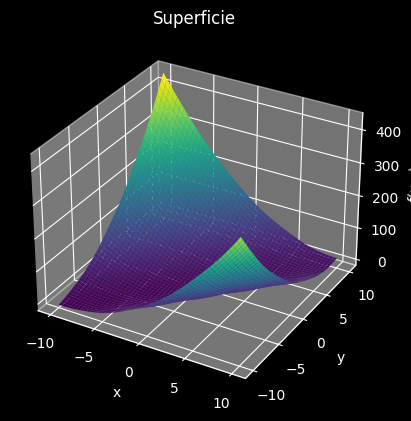

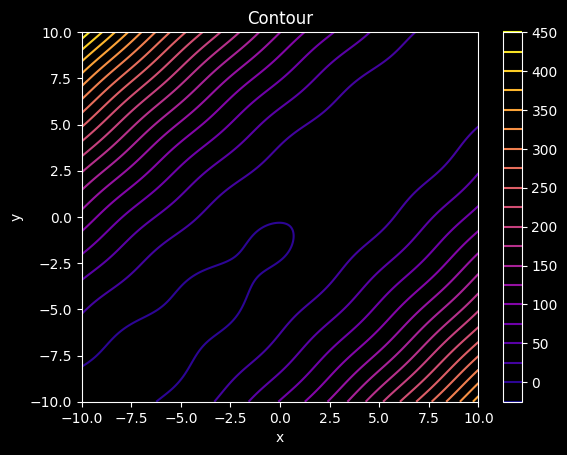

In [4]:

def f0(x, y, lib):
    return lib.sin(x + y) + (x - y) ** 2 - 1.5 * x + 2.5 * y + 1

def gradient0(x, y):
    nx = torch.cos(x + y) + 2*(x - y) - 1.5
    ny = torch.cos(x + y) - 2*(x - y) + 2.5
    return torch.tensor([nx, ny])

func0 = Function(f0,gradient0)
plot.make_surface(func0)
plot.make_contour(func0)
plot.show()

# Funcion 1
No es convexa, si tiene punto mínimo absoluto, en (1,1) y tiene múltiples puntos silla.

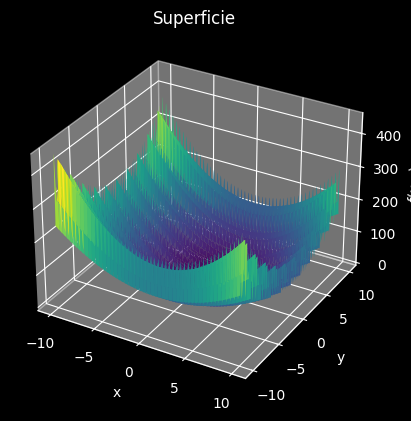

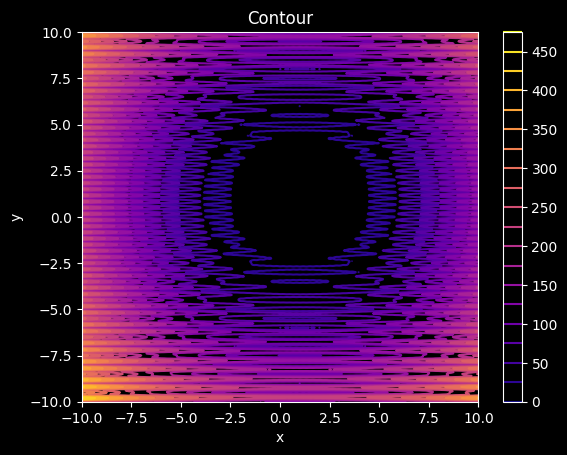

In [5]:
def gradient1(x,y):
    nx = (6*PI*torch.sin(3*PI*x)*torch.cos(3*PI*x))+(2*(x-1)*(1+(torch.sin(3*PI*y)**2)))
    ny = ((x-1)**2)*(6*PI*torch.sin(3*PI*y)*torch.cos(3*PI*y))+(2*(y-1)*(1+(torch.sin(2*PI*y)**2)))+((y-1)**2)*(4*PI*torch.sin(2*PI*y)*torch.cos(2*PI*y))
    return torch.tensor([nx, ny])

def f1(x, y, lib):
    return (lib.sin(3 * lib.pi * x) ** 2) + ((x - 1) ** 2) * (1 + (lib.sin(3 * lib.pi * y) ** 2)) + ((y - 1) ** 2) * (1 + lib.sin(2 * lib.pi * y) ** 2)

func1 = Function(f1,gradient1)
plot.make_surface(func1)
plot.make_contour(func1)
plot.show()

# Funcion 2
No es convexa, tiene 4 puntos mímimos absolutos, tiene un mínimo local

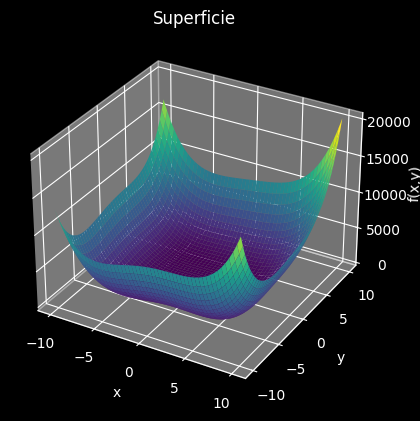

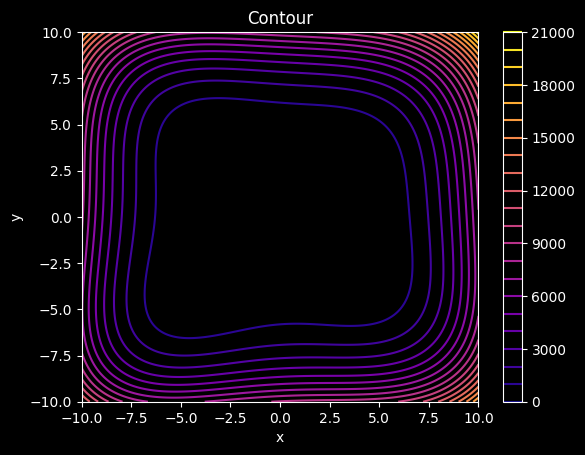

In [6]:
def gradient2(x,y):
    nx = 2*(x**2 + y - 11)*(2*x) + 2*(x + y**2 - 7)
    ny = 2*(x**2 + y - 11) + 2*(x + y**2 - 7)*(2*y)
    return torch.tensor([nx, ny])

def f2(x,y,lib):
    return (x ** 2 + y - 11) ** 2 + ((x + y ** 2 - 7) ** 2)

func2 = Function(f2,gradient2)
plot.make_surface(func2)
plot.make_contour(func2)
plot.show()

# Descenso Gradiente

In [7]:
class GradientDescent:
    def __init__(self, fun: Function, table : Table):
        self.T = 25
        self.fun = fun
        self.x0=torch.tensor([2, 1])
        self.table = table

    def descent(self, alpha: float, x_t):
        puntos=[]
        imagen=[]
        for i in range(self.T):
            x_t = x_t - alpha * self.fun.gradient(x_t)
            #x_t = torch.clamp(x_t, -10, 10)
            puntos.append(x_t.tolist())
            val=self.fun.f(x_t[0], x_t[1], torch)
            imagen.append(val.item())
            if torch.isnan(val) or torch.isinf(val):
                puntos.append([float("inf"), float("inf")])
                imagen.append(float("inf"))
                break
        return puntos, imagen

    def objetive(self, trial):
        alpha=trial.suggest_float("alpha", 1e-5, 1e-1, log=True)
        _, z= self.descent(alpha, self.x0)
        return z[-1]

    def study(self):
        self.x0=torch.tensor([5.0, 5.0])
        stud = optuna.create_study(direction="minimize")
        stud.optimize(self.objetive, n_trials=50)
        print(stud.best_params)
        optuna.visualization.plot_optimization_history(stud).show()
        optuna.visualization.plot_slice(stud, params=["alpha"]).show()
        return stud.best_params

    def show_contour(self, alpha, init):
        points, images = self.descent(alpha, init)
        plot.make_contour_p(self.fun, [x[0] for x in points], [x[1] for x in points])
        plot.make_surface_p(self.fun, [x[0] for x in points], [x[1] for x in points], images)
        plot.show()

    def run(self):
        best=self.study()
        alpha=best["alpha"]
        it=0
        best_dist = [math.inf, math.inf]
        best_init = torch.tensor([math.inf, math.inf])
        for i in initial_points:
            pts, img=self.descent(alpha, i)
            idx=img.index(min(img))
            self.table.add(it, "Iteration", idx)
            self.table.add(it, "X", i[0].item())
            self.table.add(it, "Y", i[1].item())
            self.table.add(it, "Alpha", alpha)
            self.table.add(it, "Z min", min(img))
            self.table.add(it, "Z max", max(img))
            self.table.add(it, "Z end", img[-1])
            self.table.add(it, "X min", pts[idx][0])
            self.table.add(it, "Y min", pts[idx][1])
            if [min(img), idx] < best_dist:
                best_dist = [min(img), idx]
                best_init = i
            it+=1
        self.table.show()
        self.show_contour(alpha, best_init)


# RMS Prop

In [8]:
class RMSProp:
    def __init__(self, fun: Function, table : Table):
        self.T = 25
        self.fun = fun
        self.x0=torch.tensor([2, 1])
        self.table = table

    def descent(self, x_t, rho: float, gamma: float):
        points = []
        images = []
        eps = 1e-15
        si = torch.zeros(2, dtype=torch.float32)
        for i in range(self.T):
            grad = self.fun.gradient(x_t)
            si = si * gamma + grad * grad * (1 - gamma)
            alpha = rho / torch.sqrt(si + eps)
            x_t = x_t - alpha * grad
            points.append(x_t.tolist())
            val=self.fun.f(x_t[0], x_t[1], torch)
            images.append(val.item())
        return points, images

    def objetive(self, trial):
        rho = trial.suggest_float("rho", 1e-11, 1, log=True)
        gamma = trial.suggest_float("gamma", 1e-11, 1, log=True)
        _, z= self.descent(self.x0, rho, gamma)
        return z[-1]

    def study(self):
        self.x0=torch.tensor([5.0, 5.0])
        stud = optuna.create_study(direction="minimize")
        stud.optimize(self.objetive, n_trials=50)
        print(stud.best_params)
        optuna.visualization.plot_optimization_history(stud).show()
        optuna.visualization.plot_slice(stud, params=["rho", "gamma"]).show()
        return stud.best_params

    def show_contour(self,gamma, rho, init):
        pts, img = self.descent(init,rho,gamma)
        plot.make_contour_p(self.fun, [x[0] for x in pts], [x[1] for x in pts])
        plot.make_surface_p(self.fun, [x[0] for x in pts], [x[1] for x in pts], img)
        plot.show()

    def run(self):
        best = self.study()
        rho, gamma = best["rho"], best["gamma"]
        it = 0
        best_dist = [math.inf, math.inf]
        best_init = torch.tensor([math.inf, math.inf])
        for i in initial_points:
            points, images = self.descent(i, rho, gamma)
            idx=images.index(min(images))
            self.table.add(it, "X", i[0].item())
            self.table.add(it, "Y", i[1].item())
            self.table.add(it, "Rho", rho)
            self.table.add(it, "Gamma", gamma)
            self.table.add(it, "Z min", min(images))
            self.table.add(it, "Iteration", idx)
            self.table.add(it, "Z max", max(images))
            self.table.add(it, "Z end", images[-1])
            self.table.add(it, "X min", points[idx][0])
            self.table.add(it, "Y min", points[idx][1])
            if [min(images), idx] < best_dist:
                best_dist = [min(images), idx]
                best_init = i
            it += 1
        self.table.show()
        self.show_contour(gamma, rho, best_init)


# Análisis con Optuna

[I 2026-03-25 00:32:43,475] A new study created in memory with name: no-name-5bbeb5a7-bb58-48c9-921b-e679f8bc8904
[I 2026-03-25 00:32:43,482] Trial 0 finished with value: 4.685596466064453 and parameters: {'alpha': 0.006619499209760054}. Best is trial 0 with value: 4.685596466064453.
[I 2026-03-25 00:32:43,490] Trial 1 finished with value: 5.39415168762207 and parameters: {'alpha': 0.00030953079527219096}. Best is trial 0 with value: 4.685596466064453.
[I 2026-03-25 00:32:43,496] Trial 2 finished with value: 5.441289901733398 and parameters: {'alpha': 7.187887427253922e-05}. Best is trial 0 with value: 4.685596466064453.
[I 2026-03-25 00:32:43,501] Trial 3 finished with value: 5.374463081359863 and parameters: {'alpha': 0.00041208077175703084}. Best is trial 0 with value: 4.685596466064453.
[I 2026-03-25 00:32:43,507] Trial 4 finished with value: 4.967565536499023 and parameters: {'alpha': 0.0031700411906965035}. Best is trial 0 with value: 4.685596466064453.
[I 2026-03-25 00:32:43,511

{'alpha': 0.09860529554476417}


     X    Y     Alpha  Iteration     Z min      Z max     Z end     X min  \
0  8.0  5.0  0.098605       24.0  4.370166   7.983554  4.370166  5.746787   
1 -2.0 -3.0  0.098605       24.0 -5.053816  -1.673443 -5.053816 -3.664873   
2 -1.0  0.0  0.098605       24.0 -1.913194  -0.069572 -1.913194 -0.543134   
3 -4.0 -8.0  0.098605       24.0 -8.196161  -2.535172 -8.196161 -6.818483   
4  3.0  9.0  0.098605       24.0  4.370017  23.098179  4.370017  5.741586   
5  1.0  8.0  0.098605       24.0  4.370739  28.347958  4.370739  5.714699   
6  3.0 -7.0  0.098605       24.0 -1.897004  28.456583 -1.897004 -0.646006   
7  6.0 -4.0  0.098605       24.0 -1.735213  31.612576 -1.735213 -0.239419   
8  6.0  6.0  0.098605       24.0  4.370016   5.495343  4.370016  5.741597   
9 -9.0 -2.0  0.098605       24.0 -8.193818  18.915316 -8.193818 -6.792002   

      Y min  
0  4.746779  
1 -4.664873  
2 -1.543127  
3 -7.818494  
4  4.741611  
5  4.714728  
6 -1.646038  
7 -1.239451  
8  4.741601  
9 -7.791973 

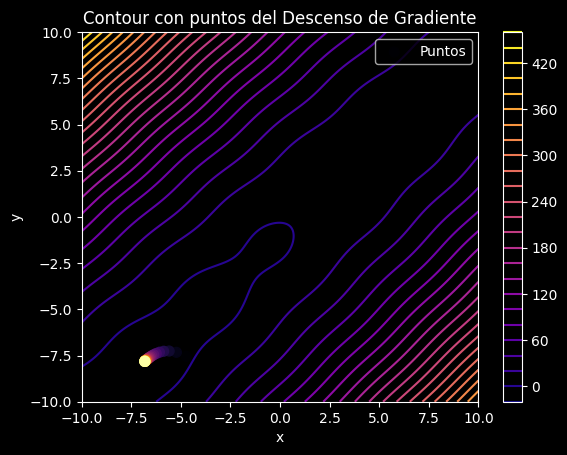

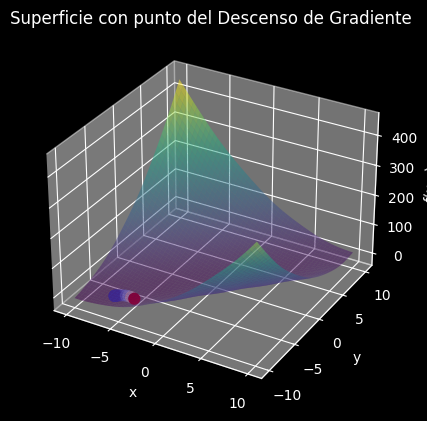

In [9]:
GD0 = GradientDescent(func0, Table(pd.DataFrame(), ["X","Y","Alpha","Iteration","Z min", "Z max","Z end", "X min", "Y min"]))
GD0.run()

[I 2026-03-25 00:32:46,828] A new study created in memory with name: no-name-e449d185-6643-4092-b3d3-f5307fa28924
[I 2026-03-25 00:32:46,843] Trial 0 finished with value: 4.467249870300293 and parameters: {'rho': 0.5297322323355658, 'gamma': 0.0006109499269843151}. Best is trial 0 with value: 4.467249870300293.
[I 2026-03-25 00:32:46,849] Trial 1 finished with value: 4.532111167907715 and parameters: {'rho': 0.014496509184754116, 'gamma': 0.039389605312191225}. Best is trial 0 with value: 4.467249870300293.
[I 2026-03-25 00:32:46,856] Trial 2 finished with value: 5.4559783935546875 and parameters: {'rho': 4.856014569069694e-08, 'gamma': 5.335474394980426e-09}. Best is trial 0 with value: 4.467249870300293.
[I 2026-03-25 00:32:46,863] Trial 3 finished with value: 5.443902969360352 and parameters: {'rho': 0.00012107944749154988, 'gamma': 0.003343350146376038}. Best is trial 0 with value: 4.467249870300293.
[I 2026-03-25 00:32:46,870] Trial 4 finished with value: 5.455645561218262 and par

{'rho': 0.055040657105951504, 'gamma': 1.5761808037041128e-05}


     X    Y       Rho     Gamma  Iteration      Z min      Z max      Z end  \
0  8.0  5.0  0.055041  0.000016       24.0   5.387801  10.491955   5.387801   
1 -2.0 -3.0  0.055041  0.000016       24.0  -4.870823  -1.633084  -4.870823   
2 -1.0  0.0  0.055041  0.000016       24.0  -1.876161   2.230319  -1.876161   
3 -4.0 -8.0  0.055041  0.000016       24.0  -5.596872   2.888195  -5.596872   
4  3.0  9.0  0.055041  0.000016       24.0  23.508678  52.934391  23.508678   
5  1.0  8.0  0.055041  0.000016       24.0  32.453236  67.162918  32.453236   
6  3.0 -7.0  0.055041  0.000016       24.0  37.793839  77.787430  37.793839   
7  6.0 -4.0  0.055041  0.000016       24.0  40.946342  80.939926  40.946342   
8  6.0  6.0  0.055041  0.000016       22.0   4.370090   6.255380   4.370092   
9 -9.0 -2.0  0.055041  0.000016       24.0  23.041193  57.750786  23.041193   

      X min     Y min  
0  6.623980  5.055033  
1 -3.376016 -4.376015  
2 -0.504617 -1.376015  
3 -5.376019 -6.954258  
4  4.37601

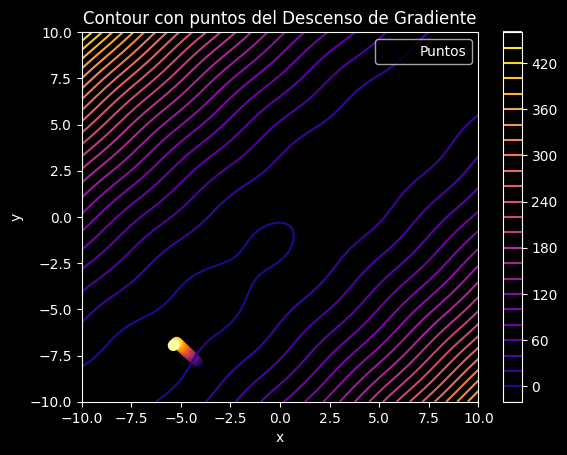

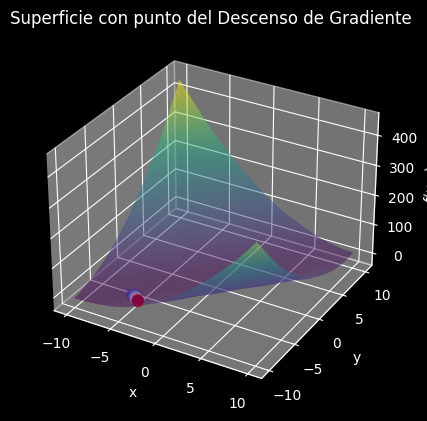

In [10]:
RMS0 = RMSProp(func0, Table(pd.DataFrame(), ["X","Y","Rho","Gamma","Iteration","Z min", "Z max","Z end", "X min", "Y min"]))
RMS0.run()

[I 2026-03-25 00:32:48,184] A new study created in memory with name: no-name-3451bff0-a35d-4453-90a7-eb1c9a22188c
[I 2026-03-25 00:32:48,195] Trial 0 finished with value: 38.07342529296875 and parameters: {'alpha': 0.000584697059456892}. Best is trial 0 with value: 38.07342529296875.
[I 2026-03-25 00:32:48,208] Trial 1 finished with value: 18.043493270874023 and parameters: {'alpha': 0.00889494135373192}. Best is trial 1 with value: 18.043493270874023.
[I 2026-03-25 00:32:48,217] Trial 2 finished with value: 23.664222717285156 and parameters: {'alpha': 0.0038124248946805953}. Best is trial 1 with value: 18.043493270874023.
[I 2026-03-25 00:32:48,222] Trial 3 finished with value: inf and parameters: {'alpha': 0.02473315324929995}. Best is trial 1 with value: 18.043493270874023.
[I 2026-03-25 00:32:48,235] Trial 4 finished with value: 33.253082275390625 and parameters: {'alpha': 0.0030405892915563123}. Best is trial 1 with value: 18.043493270874023.
[I 2026-03-25 00:32:48,247] Trial 5 fi

{'alpha': 0.030852640126204357}


[W 2026-03-25 00:32:48,767] Trial 3 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:48,768] Trial 9 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:48,768] Trial 10 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:48,769] Trial 11 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:48,769] Trial 13 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:48,770] Trial 21 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:48,770] Trial 31 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:48,771] Trial 39 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:48,771] Trial 43 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:48,771] Tr

     X    Y     Alpha  Iteration       Z min       Z max     Z end     X min  \
0  8.0  5.0  0.030853        0.0   94.805061         inf       inf  7.568063   
1 -2.0 -3.0  0.030853        2.0    8.223893         inf       inf -0.965865   
2 -1.0  0.0  0.030853       19.0    0.142393   40.326668  0.380185  1.006905   
3 -4.0 -8.0  0.030853       22.0    0.395128  267.932465  0.502197  0.637051   
4  3.0  9.0  0.030853        0.0   64.308830         inf       inf  2.876589   
5  1.0  8.0  0.030853       24.0    0.000653   50.553879  0.000653  1.000000   
6  3.0 -7.0  0.030853        0.0   64.305687         inf       inf  2.876589   
7  6.0 -4.0  0.030853        1.0   28.700422         inf       inf  5.255391   
8  6.0  6.0  0.030853       24.0    2.230509   93.510696  2.230509  1.071206   
9 -9.0 -2.0  0.030853        1.0  150.594620         inf       inf -7.008330   

      Y min  
0  4.753167  
1  1.881371  
2  1.263226  
3  0.682386  
4  8.506363  
5  0.974750  
6 -6.506283  
7  2.59

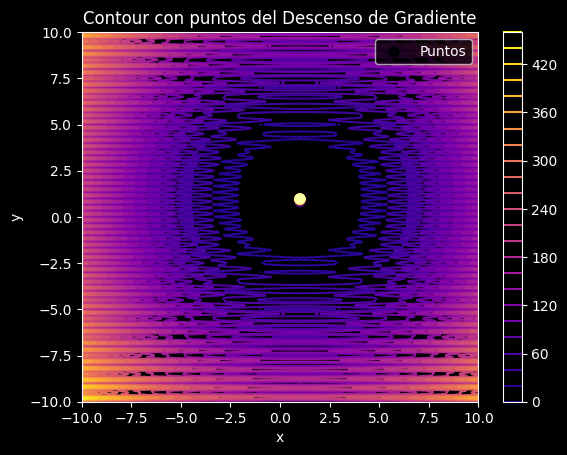

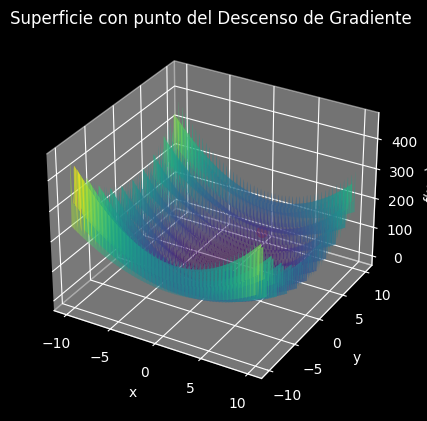

In [11]:
GD1 = GradientDescent(func1, Table(pd.DataFrame(), ["X","Y","Alpha","Iteration","Z min", "Z max","Z end"]))
GD1.run()

[I 2026-03-25 00:32:49,832] A new study created in memory with name: no-name-218059c9-4509-4940-bb44-18480e3f4619
[I 2026-03-25 00:32:49,845] Trial 0 finished with value: 32.0 and parameters: {'rho': 4.755010698464992e-10, 'gamma': 0.0038235098350213144}. Best is trial 0 with value: 32.0.
[I 2026-03-25 00:32:49,857] Trial 1 finished with value: 32.0 and parameters: {'rho': 6.6414909464924364e-09, 'gamma': 0.0030755511103476487}. Best is trial 0 with value: 32.0.
[I 2026-03-25 00:32:49,867] Trial 2 finished with value: 24.992206573486328 and parameters: {'rho': 0.19801674566134975, 'gamma': 3.235688326966707e-08}. Best is trial 2 with value: 24.992206573486328.
[I 2026-03-25 00:32:49,879] Trial 3 finished with value: 51.19733428955078 and parameters: {'rho': 0.1785165487778938, 'gamma': 3.6977526291962524e-07}. Best is trial 2 with value: 24.992206573486328.
[I 2026-03-25 00:32:49,889] Trial 4 finished with value: 31.862476348876953 and parameters: {'rho': 0.0008540339267568148, 'gamma'

{'rho': 0.9498003030017118, 'gamma': 1.0282666046413335e-11}


     X    Y     Rho  Gamma  Iteration      Z min       Z max      Z end  \
0  8.0  5.0  0.9498    0.0        4.0  12.704369   54.611820  12.704369   
1 -2.0 -3.0  0.9498    0.0        5.0   2.190541   15.482720   3.217189   
2 -1.0  0.0  0.9498    0.0        0.0   1.542315   30.162149  30.162149   
3 -4.0 -8.0  0.9498    0.0        4.0  44.012615   91.059685  44.012615   
4  3.0  9.0  0.9498    0.0        7.0  14.486826   56.028080  23.190237   
5  1.0  8.0  0.9498    0.0        4.0  23.199539   45.574951  23.199539   
6  3.0 -7.0  0.9498    0.0        5.0  14.486815   56.028038  23.190239   
7  6.0 -4.0  0.9498    0.0       15.0   6.390105   38.000473   7.997339   
8  6.0  6.0  0.9498    0.0        3.0   6.390105   38.000416   7.997341   
9 -9.0 -2.0  0.9498    0.0       10.0   1.211002  111.087860   1.211003   

      X min     Y min  
0  3.250998  2.150599  
1  1.799201  0.799201  
2 -0.050200  0.949800  
3 -1.150599 -3.250998  
4 -0.799201  3.301197  
5 -1.847060  3.250998  
6 -0.7

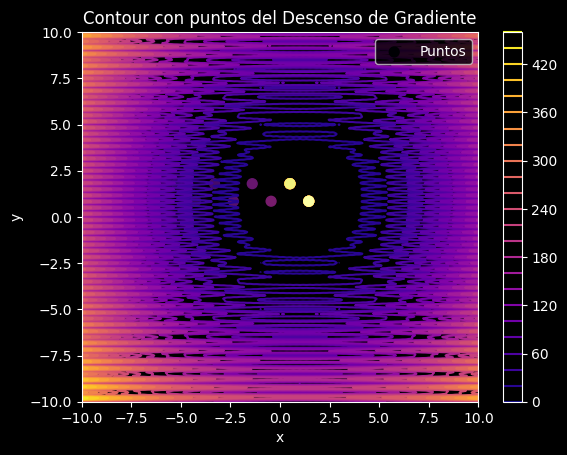

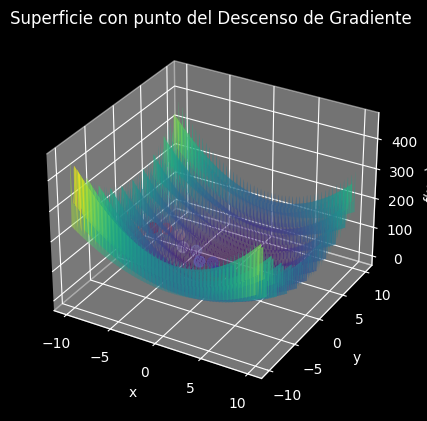

In [12]:
RMS1 = RMSProp(func1, Table(pd.DataFrame(), ["X","Y","Rho","Gamma","Iteration","Z min", "Z max","Z end"]))
RMS1.run()

[I 2026-03-25 00:32:51,448] A new study created in memory with name: no-name-97883f33-7304-4c27-850d-482697f47072
[I 2026-03-25 00:32:51,457] Trial 0 finished with value: 763.02734375 and parameters: {'alpha': 1.3083708406162314e-05}. Best is trial 0 with value: 763.02734375.
[I 2026-03-25 00:32:51,463] Trial 1 finished with value: 743.711669921875 and parameters: {'alpha': 1.5326797332842175e-05}. Best is trial 1 with value: 743.711669921875.
[I 2026-03-25 00:32:51,465] Trial 2 finished with value: inf and parameters: {'alpha': 0.02208740105594678}. Best is trial 1 with value: 743.711669921875.
[I 2026-03-25 00:32:51,470] Trial 3 finished with value: 676.078857421875 and parameters: {'alpha': 2.383047281195496e-05}. Best is trial 3 with value: 676.078857421875.
[I 2026-03-25 00:32:51,478] Trial 4 finished with value: 535.474365234375 and parameters: {'alpha': 4.572606995654461e-05}. Best is trial 4 with value: 535.474365234375.
[I 2026-03-25 00:32:51,480] Trial 5 finished with value: 

{'alpha': 0.006838335802513601}


[W 2026-03-25 00:32:51,788] Trial 2 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:51,789] Trial 5 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:51,789] Trial 8 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:51,790] Trial 18 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:51,790] Trial 27 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:51,791] Trial 33 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:51,791] Trial 34 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:51,792] Trial 44 is omitted in visualization because its objective value is inf or nan.
[W 2026-03-25 00:32:51,792] Trial 45 is omitted in visualization because its objective value is inf or nan.


     X    Y     Alpha  Iteration        Z min        Z max     Z end  \
0  8.0  5.0  0.006838       24.0     0.000000   363.989105  0.000000   
1 -2.0 -3.0  0.006838       24.0     0.000000    56.220409  0.000000   
2 -1.0  0.0  0.006838       24.0     0.000000   156.750946  0.000000   
3 -4.0 -8.0  0.006838       24.0     0.000000   331.658661  0.000000   
4  3.0  9.0  0.006838        0.0  9469.943359          inf       inf   
5  1.0  8.0  0.006838       24.0     0.000530   468.840881  0.000530   
6  3.0 -7.0  0.006838       24.0     0.000156     0.968051  0.000156   
7  6.0 -4.0  0.006838       24.0     0.000054    71.640099  0.000054   
8  6.0  6.0  0.006838       24.0     0.237981   163.311249  0.237981   
9 -9.0 -2.0  0.006838       24.0     0.000000  2483.230225  0.000000   

      X min      Y min  
0 -2.805116   3.131310  
1 -3.779310  -3.283186  
2 -2.805096   3.131305  
3 -2.805118   3.131312  
4  1.372476 -10.051603  
5  3.583875  -1.842065  
6  3.001330   1.996777  
7  3.58

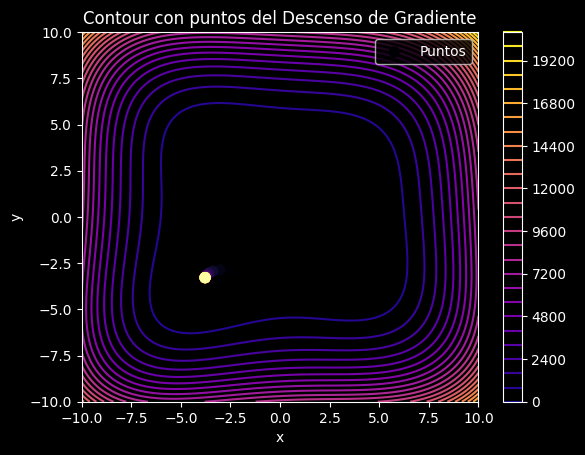

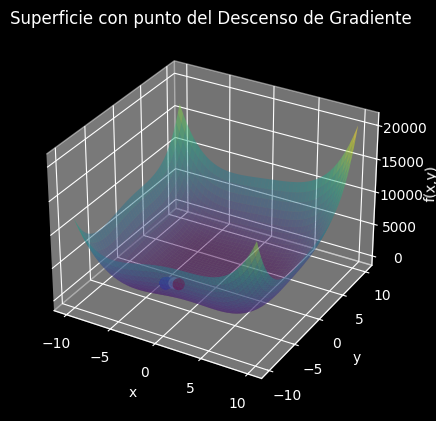

In [13]:
GD2 = GradientDescent(func2, Table(pd.DataFrame(), ["X","Y","Alpha","Iteration","Z min", "Z max","Z end"]))
GD2.run()

[I 2026-03-25 00:32:52,736] A new study created in memory with name: no-name-6a5bb9f5-b7ac-40f7-b777-feeaad3d6357
[I 2026-03-25 00:32:52,744] Trial 0 finished with value: 890.0 and parameters: {'rho': 1.6535093059133143e-07, 'gamma': 3.932321634446973e-09}. Best is trial 0 with value: 890.0.
[I 2026-03-25 00:32:52,751] Trial 1 finished with value: 889.70263671875 and parameters: {'rho': 1.2992299776009104e-05, 'gamma': 8.934623416188589e-10}. Best is trial 1 with value: 889.70263671875.
[I 2026-03-25 00:32:52,758] Trial 2 finished with value: 890.0 and parameters: {'rho': 1.7240314481608199e-09, 'gamma': 0.001833636461935355}. Best is trial 1 with value: 889.70263671875.
[I 2026-03-25 00:32:52,765] Trial 3 finished with value: 696.6915893554688 and parameters: {'rho': 0.00907247565678839, 'gamma': 1.5771941549913428e-08}. Best is trial 3 with value: 696.6915893554688.
[I 2026-03-25 00:32:52,771] Trial 4 finished with value: 710.3780517578125 and parameters: {'rho': 0.008377380944769147

{'rho': 0.15522775292563407, 'gamma': 2.993811008600304e-05}


     X    Y       Rho    Gamma  Iteration       Z min        Z max  \
0  8.0  5.0  0.155228  0.00003       24.0   52.891075  3658.814209   
1 -2.0 -3.0  0.155228  0.00003       11.0    0.383686    85.764389   
2 -1.0  0.0  0.155228  0.00003       19.0    0.140447   156.559509   
3 -4.0 -8.0  0.155228  0.00003       24.0   38.399773  2541.159668   
4  3.0  9.0  0.155228  0.00003       24.0  361.929047  5522.318359   
5  1.0  8.0  0.155228  0.00003       24.0   52.250965  3073.480225   
6  3.0 -7.0  0.155228  0.00003       24.0   42.350159  1911.766235   
7  6.0 -4.0  0.155228  0.00003       15.0    0.234650   558.825500   
8  6.0  6.0  0.155228  0.00003       24.0    0.474678  1930.756836   
9 -9.0 -2.0  0.155228  0.00003       24.0  134.891876  4360.153809   

        Z end     X min     Y min  
0   52.891075  4.119319  1.119327  
1    1.953240 -3.862656 -3.302031  
2    1.009103 -2.862778  3.104552  
3   38.399773 -4.154993 -4.119319  
4  361.929047 -0.880688  5.119313  
5   52.250965

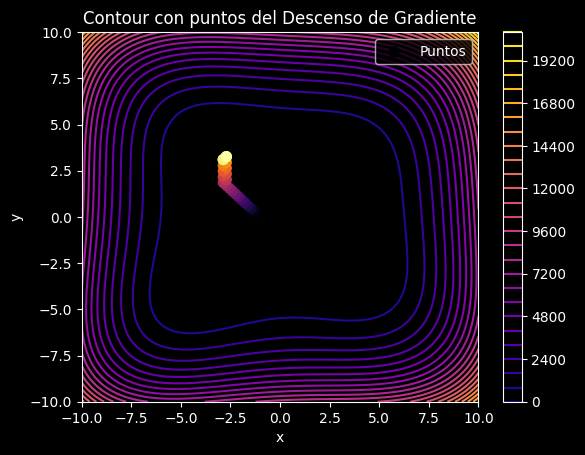

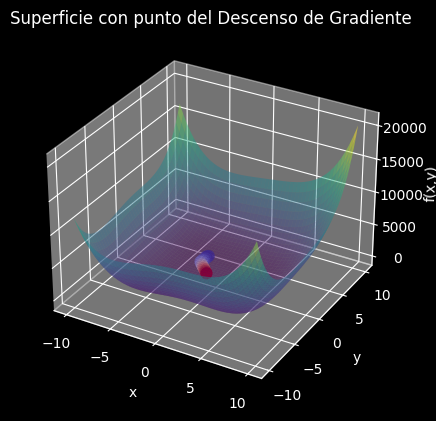

In [14]:
RMS2 = RMSProp(func2, Table(pd.DataFrame(), ["X","Y","Rho","Gamma","Iteration","Z min", "Z max","Z end"]))
RMS2.run()